In [130]:
import pandas as pd

In [131]:
df=pd.read_csv("/content/taitanic dataset.csv")

In [132]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [133]:
df.shape

(891, 12)

In [134]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [136]:
df=df.drop("Cabin",axis=1)

In [137]:
df=df.drop("Name",axis=1)

In [138]:
df.shape

(891, 10)

In [139]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [140]:
Sex={'male':0,'female':1}
df['Sex']=df['Sex'].map(Sex)

In [141]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,1,35.0,1,0,113803,53.1000,S
4,5,0,3,0,35.0,0,0,373450,8.0500,S


In [142]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [143]:
df['Embarked'].isna().sum()

np.int64(2)

In [144]:
df['Embarked'].fillna(df['Embarked'].bfill(), inplace=True)

/tmp/ipykernel_1881/2973510638.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].bfill(), inplace=True)


In [145]:
df['Embarked']= df['Embarked'].replace('C',0 )
df['Embarked']= df['Embarked'].replace('S',1 )
df['Embarked']=df['Embarked'].replace('Q',2 )

/tmp/ipykernel_1881/3822175013.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Embarked']=df['Embarked'].replace('Q',2 )


In [146]:
df['Embarked'].isna().sum()

np.int64(0)

In [147]:
df['Ticket']=df['Ticket']

In [148]:
X=df.drop(['Survived','Ticket'],axis=1)
y=df['Survived']

In [149]:
df['Famliy']=df['SibSp']+df['Parch']

In [150]:
df.sample(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Famliy
134,135,0,2,0,25.000000,0,0,C.A. 29178,13.0,1,0
732,733,0,2,0,29.699118,0,0,239855,0.0,1,0


<Axes: ylabel='Survived'>

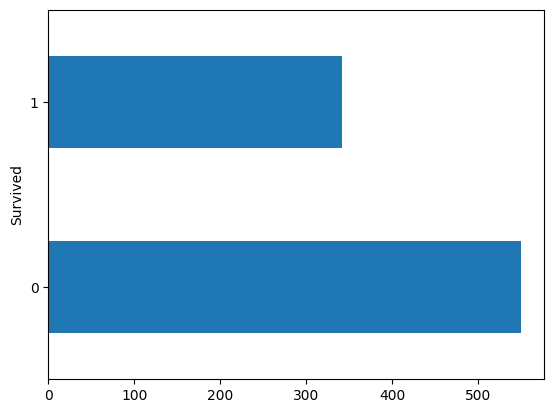

In [151]:
df['Survived'].value_counts().plot(kind='barh')# 1=yesSurvived',0=noSurvived'

In [152]:
survival_rate_by_sex = df.groupby('Sex')['Survived'].mean().reset_index()
display(survival_rate_by_sex)

,Sex,Survived
0,0,0.188908
1,1,0.742038


/tmp/ipykernel_1881/1506620500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=survival_rate_by_sex, palette='viridis')


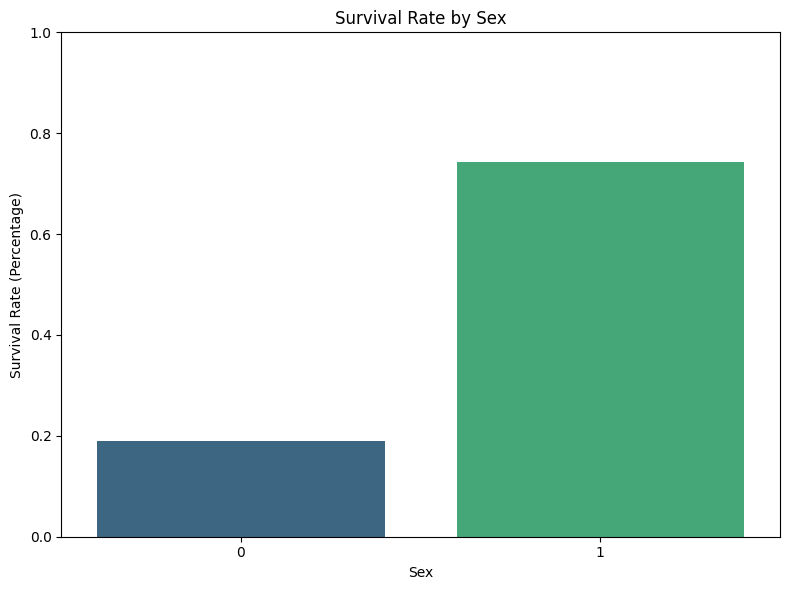

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(8, 6))
sns.barplot(x='Sex', y='Survived', data=survival_rate_by_sex, palette='viridis')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate (Percentage)')
plt.ylim(0, 1) # Survival rate 0 se 1 ke beech hoti hai
plt.tight_layout()
plt.show()

In [154]:
survival_rate_by_family = df.groupby('Famliy')['Survived'].mean().reset_index()
display(survival_rate_by_family)

,Famliy,Survived
0,0,0.303538
1,1,0.552795
2,2,0.578431
3,3,0.724138
4,4,0.200000
5,5,0.136364
6,6,0.333333
7,7,0.000000
8,10,0.000000


/tmp/ipykernel_1881/813099484.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Famliy', y='Survived', data=survival_rate_by_family, palette='viridis')


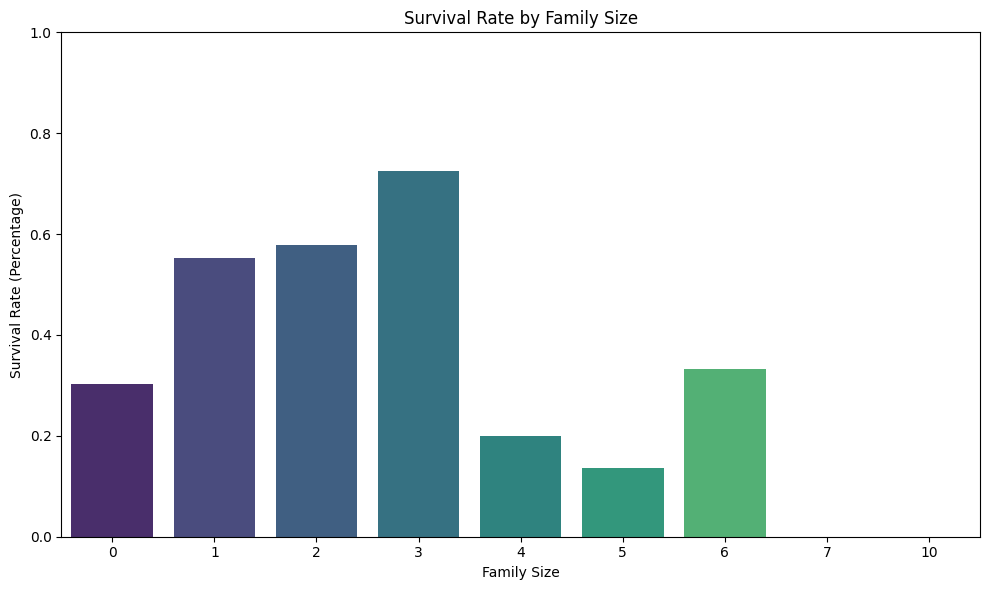

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Famliy', y='Survived', data=survival_rate_by_family, palette='viridis')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate (Percentage)')
plt.ylim(0, 1) # Survival rate 0 se 1 ke beech hoti hai
plt.xticks(rotation=0) # X-axis labels ko rotate karne ki zaroorat nahi hai agar overlap na ho
plt.tight_layout()
plt.show()

In [156]:
from sklearn.preprocessing import StandardScaler
#create a scaler object
scalar=StandardScaler()
#fit and transform the data
x_scaled=scalar.fit_transform(X)
print(x_scaled)

[[-1.73010796  0.82737724 -0.73769513 ... -0.47367361 -0.50244517
   0.20041623]
 [-1.72622007 -1.56610693  1.35557354 ... -0.47367361  0.78684529
  -1.74057139]
 [-1.72233219  0.82737724  1.35557354 ... -0.47367361 -0.48885426
   0.20041623]
 ...
 [ 1.72233219  0.82737724  1.35557354 ...  2.00893337 -0.17626324
   0.20041623]
 [ 1.72622007 -1.56610693 -0.73769513 ... -0.47367361 -0.04438104
  -1.74057139]
 [ 1.73010796  0.82737724 -0.73769513 ... -0.47367361 -0.49237783
   2.14140384]]


In [167]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [168]:
X_train.shape

(712, 8)

In [169]:
X_test.shape

(179, 8)

In [170]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
accuracy_rf=rf_model.score(X_test,y_test)
print(accuracy_rf)

0.8268156424581006


In [175]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
from sklearn.ensemble import RandomForestClassifier
y_pred = rf_model.predict(X_test)
print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred))


Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [178]:
df.to_csv('cleaned_titanic_dataset.csv', index=False)